In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report

In [2]:
data = pd.read_csv('Diabetes.csv', encoding='latin-1')

In [3]:
data

,age_years,bmi_prepreg,fh_diabetes,hx_diabetes,Blood_suger_week_8,Bloog_suger_OGTT_Fasting,Blood_suger_OGTT_one_hour,Blood_suger_OGTT_two_hour,Result
0,28,34.0,YES,YES,300.0,126.0,196.0,146.0,95
1,22,29.0,YES,NO,108.0,102.0,173.0,143.0,66
2,34,29.0,YES,NO,107.7,112.2,178.0,143.2,64
3,21,29.6,YES,NO,108.0,121.0,178.0,146.0,49
4,30,30.0,YES,YES,152.0,284.0,268.0,149.0,92
...,...,...,...,...,...,...,...,...,...
1157,24,19.0,NO,NO,85.0,74.0,114.0,95.0,0
1158,31,32.3,YES,YES,281.0,197.0,256.0,150.0,79
1159,24,27.3,NO,NO,96.0,96.7,148.0,132.7,29
1160,26,25.0,NO,NO,97.0,97.0,158.0,132.0,12


<Axes: >

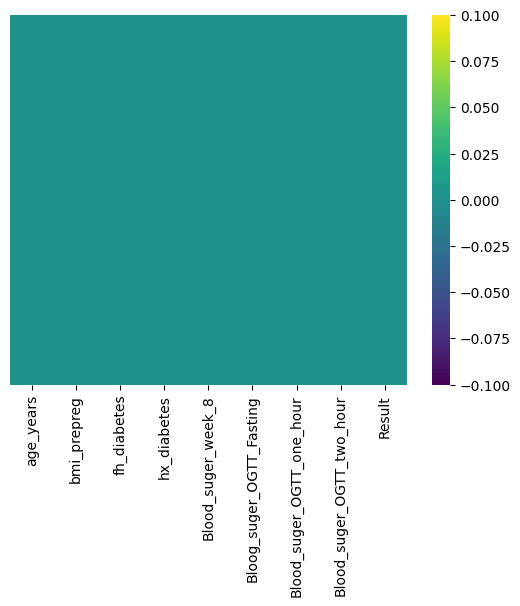

In [4]:
sns.heatmap(data.isnull(),yticklabels=False, cmap="viridis")

In [5]:
data.isnull().sum()

age_years                    0
bmi_prepreg                  0
fh_diabetes                  0
hx_diabetes                  0
Blood_suger_week_8           0
Bloog_suger_OGTT_Fasting     0
Blood_suger_OGTT_one_hour    0
Blood_suger_OGTT_two_hour    0
Result                       0
dtype: int64

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162 entries, 0 to 1161
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  1162 non-null   int64  
 1   bmi_prepreg                1162 non-null   float64
 2   fh_diabetes                1162 non-null   object 
 3   hx_diabetes                1162 non-null   object 
 4   Blood_suger_week_8         1162 non-null   float64
 5   Bloog_suger_OGTT_Fasting   1162 non-null   float64
 6   Blood_suger_OGTT_one_hour  1162 non-null   float64
 7   Blood_suger_OGTT_two_hour  1162 non-null   float64
 8   Result                     1162 non-null   int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 81.8+ KB


In [7]:
data['fh_diabetes'].value_counts()

fh_diabetes
NO     625
YES    537
Name: count, dtype: int64

In [8]:
data = data.drop('hx_diabetes', axis=1)

In [9]:
data['fh_diabetes'] = data['fh_diabetes'].str.replace('NO', '0', regex=False)
data['fh_diabetes'] = data['fh_diabetes'].str.replace('YES', '1', regex=False)

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162 entries, 0 to 1161
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  1162 non-null   int64  
 1   bmi_prepreg                1162 non-null   float64
 2   fh_diabetes                1162 non-null   object 
 3   Blood_suger_week_8         1162 non-null   float64
 4   Bloog_suger_OGTT_Fasting   1162 non-null   float64
 5   Blood_suger_OGTT_one_hour  1162 non-null   float64
 6   Blood_suger_OGTT_two_hour  1162 non-null   float64
 7   Result                     1162 non-null   int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 72.8+ KB


In [11]:
data['fh_diabetes'] = data['fh_diabetes'].apply(np.int64)

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1162 entries, 0 to 1161
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  1162 non-null   int64  
 1   bmi_prepreg                1162 non-null   float64
 2   fh_diabetes                1162 non-null   int64  
 3   Blood_suger_week_8         1162 non-null   float64
 4   Bloog_suger_OGTT_Fasting   1162 non-null   float64
 5   Blood_suger_OGTT_one_hour  1162 non-null   float64
 6   Blood_suger_OGTT_two_hour  1162 non-null   float64
 7   Result                     1162 non-null   int64  
dtypes: float64(5), int64(3)
memory usage: 72.8 KB


In [13]:
data.describe()

,age_years,bmi_prepreg,fh_diabetes,Blood_suger_week_8,Bloog_suger_OGTT_Fasting,Blood_suger_OGTT_one_hour,Blood_suger_OGTT_two_hour,Result
count,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000,1162.000000
mean,27.977625,26.705077,0.462134,126.604389,125.734854,171.776334,130.551205,38.093804
std,5.386638,4.803514,0.498779,56.217037,55.534248,48.790062,20.519397,32.641064
min,20.000000,14.600000,0.000000,70.000000,70.000000,90.000000,80.000000,0.000000
25%,24.000000,25.000000,0.000000,95.000000,95.000000,141.000000,121.000000,1.000000
50%,27.000000,28.000000,0.000000,101.000000,101.650000,170.000000,140.000000,36.000000
75%,31.000000,30.000000,1.000000,131.000000,127.350000,183.000000,146.000000,67.000000
max,43.000000,35.000000,1.000000,300.000000,300.000000,300.000000,152.000000,99.000000


In [14]:
X = data.drop('Result', axis=1)
y = data['Result']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [17]:
svr.score(X_test, y_test)

0.8835845697847764

In [18]:
from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg.score(X_test, y_test)

C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.21030042918454936

In [19]:
import pickle
# save model to file
pickle.dump(svr, open("diabetes_model.dat", "wb"))

In [20]:
predict=np.round(svr.predict(X_test))

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>


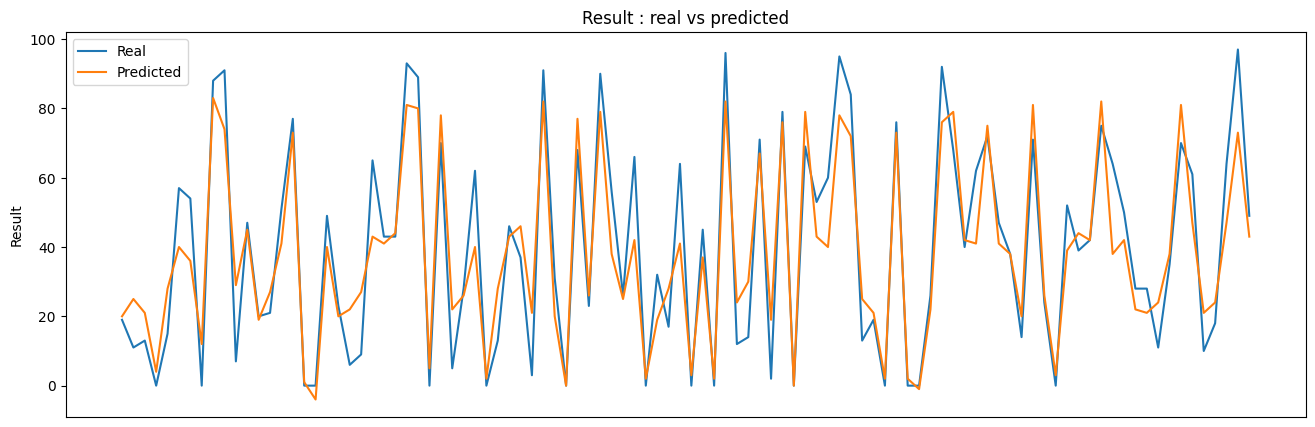

In [21]:
A = np.array(y_test).reshape(-1, 1)
B = predict.reshape(-1, 1)
print(type(predict))
print(type(y_test))
plt.rcParams['figure.figsize'] = 16,5
plt.figure()
plt.plot(A[-100:], label="Real")
plt.plot(B[-100:], label="Predicted")
plt.legend()
plt.title("Result : real vs predicted")
plt.ylabel("Result")
plt.xticks(())
plt.show()

In [22]:
with open('diabetes_model.dat' , 'rb') as f:
    model = pickle.load(f)

In [23]:
X

,age_years,bmi_prepreg,fh_diabetes,Blood_suger_week_8,Bloog_suger_OGTT_Fasting,Blood_suger_OGTT_one_hour,Blood_suger_OGTT_two_hour
0,28,34.0,1,300.0,126.0,196.0,146.0
1,22,29.0,1,108.0,102.0,173.0,143.0
2,34,29.0,1,107.7,112.2,178.0,143.2
3,21,29.6,1,108.0,121.0,178.0,146.0
4,30,30.0,1,152.0,284.0,268.0,149.0
...,...,...,...,...,...,...,...
1157,24,19.0,0,85.0,74.0,114.0,95.0
1158,31,32.3,1,281.0,197.0,256.0,150.0
1159,24,27.3,0,96.0,96.7,148.0,132.7
1160,26,25.0,0,97.0,97.0,158.0,132.0


In [24]:
X_test

,age_years,bmi_prepreg,fh_diabetes,Blood_suger_week_8,Bloog_suger_OGTT_Fasting,Blood_suger_OGTT_one_hour,Blood_suger_OGTT_two_hour
244,28,20.0,0,94.0,77.0,109.0,116.0
101,33,29.0,1,104.0,116.0,176.7,147.2
1080,38,32.8,0,187.0,251.0,222.0,144.0
583,23,27.0,0,99.0,96.0,159.0,132.0
752,32,28.0,1,109.8,109.0,179.0,148.0
...,...,...,...,...,...,...,...
920,23,25.0,0,95.0,98.5,145.0,136.0
1048,34,27.0,0,98.0,99.0,152.1,135.0
1152,29,28.0,1,124.0,123.0,172.9,152.0
994,42,32.6,0,154.0,202.0,189.0,147.0


In [25]:
y_test

244      0
101     55
1080    76
583      9
752     49
        ..
920     10
1048    18
1152    64
994     97
3       49
Name: Result, Length: 233, dtype: int64

In [28]:
import math
math.ceil(model.predict([[21,29.6,1,108.0,121.0,178.0,146.0]]))

C:\Users\Kale\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVR was fitted with feature names
  warnings.warn(
C:\Users\Kale\AppData\Local\Temp\ipykernel_10152\1631412420.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  math.ceil(model.predict([[21,29.6,1,108.0,121.0,178.0,146.0]]))


43